# In-Depth Thematic & Normative Analysis of the CycloneDX 1.6 Specification

## 1. Introduction & Objectives

This notebook provides a comprehensive, multi-faceted analysis of the normative requirements extracted from the CycloneDX 1.6 specification. The primary objective is to deconstruct the standard's structure, priorities, and prescriptive force through rigorous data visualization and quantitative analysis. The insights and figures generated here are intended to serve as foundational evidence for a Systematization of Knowledge (SoK) paper targeting a top-tier security conference.

**Analytical Workflow:**
1. **Setup & Configuration:** Import libraries and define the core thematic mapping that forms the basis of our taxonomy.
2. **Data Loading & Validation:** Ingest the `cyclonedx_thematic.csv` dataset, apply the theme mapping, standardize keywords, and perform rigorous data validation.
3. **High-Level Thematic Overview:** Start with a broad view of the thematic landscape to understand the specification's main pillars.
4. **Granular Subtheme Analysis:** Drill down into the subthemes to identify the most detailed and frequently mentioned concepts.
5. **Normative Force Analysis:** Perform a deep dive into the distribution of normative keywords (`REQUIRED`, `SHOULD`, `MAY`) to quantify the strictness of the standard.
6. **Hierarchical & Relational Analysis:** Use advanced visualizations (sunburst, treemap, tree diagram) to explore the nested structure of the taxonomy.
7. **Exploratory Text & Keyword Analysis:** Conduct NLP-based analysis to uncover the most common terms and actions within the requirements themselves.

---

## 2. Setup: Libraries, Styles, and Theme Mapping

### 2.1. Import Libraries and Define Global Styles

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import graphviz
from wordcloud import WordCloud
import squarify  # For static treemaps
import warnings

# Suppress potential warnings for cleaner output
warnings.filterwarnings('ignore')

# Set professional visualization styles for consistency and publication quality
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.title_fontsize'] = 14


### 2.2. Define the Hierarchical Theme Mapping

This is the analytical core of our thematic analysis. We define the high-level themes and create a mapping from the granular subthemes developed during open coding. This structure is based on the logical groupings of concepts within the CycloneDX specification.


In [2]:
# Define the mapping from our 19 granular subthemes to 7 high-level themes
subtheme_to_theme_map = {
    # Theme 1: Foundational BOM Structure and Identity
    'Specification Conformance': 'Foundational BOM Structure and Identity',
    'BOM Format and Versioning': 'Foundational BOM Structure and Identity',
    'BOM Identification': 'Foundational BOM Structure and Identity',
    'Root Object Model': 'Foundational BOM Structure and Identity',
    'Serialization and Schema': 'Foundational BOM Structure and Identity',
    'Internal Referencing (bom-ref)': 'Foundational BOM Structure and Identity',

    # Theme 2: Metadata and Provenance
    'BOM Metadata': 'Metadata and Provenance',
    'Organizational Entity Definition': 'Metadata and Provenance',
    'Contact Information': 'Metadata and Provenance',
    'Tooling Information': 'Metadata and Provenance',
    'Timestamping': 'Metadata and Provenance',
    'Lifecycle Information': 'Metadata and Provenance',

    # Theme 3: Core Inventory and Component Attributes
    'Component and Service Definition': 'Core Inventory and Component Attributes',
    'Component and Service Typing': 'Core Inventory and Component Attributes',
    'Component and Service Identification': 'Core Inventory and Component Attributes',
    'Standardized External Identifiers': 'Core Inventory and Component Attributes',
    'Descriptive Metadata': 'Core Inventory and Component Attributes',
    'Component Scope': 'Core Inventory and Component Attributes',

    # Theme 4: Relationships and Composition
    'Dependency Graph Representation': 'Relationships and Composition',
    'Component Assemblies (Nesting)': 'Relationships and Composition',
    'Composition and Completeness': 'Relationships and Composition',
    'External References': 'Relationships and Composition',

    # Theme 5: Trust, Integrity, and Security
    'Cryptographic Hashes': 'Trust, Integrity, and Security',
    'Digital Signatures': 'Trust, Integrity, and Security',
    'Vulnerability Information (Vulnerability Object)': 'Trust, Integrity, and Security',
    'Vulnerability Impact Analysis (VEX)': 'Trust, Integrity, and Security',
    'Component Pedigree and Provenance': 'Trust, Integrity, and Security',
    'Evidence and Substantiation': 'Trust, Integrity, and Security',

    # Theme 6: Advanced and Specialized Data Models
    'Licensing and Copyright': 'Advanced and Specialized Data Models',
    'Formulation and Reproducible Builds': 'Advanced and Specialized Data Models',
    'Cryptographic Asset Management (CBOM)': 'Advanced and Specialized Data Models',
    'AI/ML Model Cards (ML-BOM)': 'Advanced and Specialized Data Models',
    'Data Components and Governance': 'Advanced and Specialized Data Models',
    'Attestations and Declarations': 'Advanced and Specialized Data Models',
    'Annotations': 'Advanced and Specialized Data Models',

    # Theme 7: Extensibility and Customization
    'Extensibility via Properties': 'Extensibility and Customization',
    'Property Taxonomies': 'Extensibility and Customization'
}

print("✅ Theme mapping dictionary created successfully.")


✅ Theme mapping dictionary created successfully.


## 3. Data Loading, Validation, and Preparation

In this section, we load the raw `cyclonedx_thematic.csv` file, apply our theme mapping, standardize keywords, and perform rigorous data validation to ensure the integrity of our analysis.


In [3]:
# Load the dataset
try:
    df = pd.read_csv('cyclonedx_thematic.csv')
    print(f"✅ Dataset 'cyclonedx_thematic.csv' loaded successfully. Found {len(df)} requirements.")
except FileNotFoundError:
    print("❌ Error: 'cyclonedx_thematic.csv' not found. Please ensure the file is in the correct directory.")
    df = pd.DataFrame()

if not df.empty:
    # --- Data Preparation ---
    
    # 1. Apply the theme mapping
    df['Theme'] = df['Subtheme'].map(subtheme_to_theme_map)

    # 2. Standardize normative keywords
    keyword_map = {'MUST': 'REQUIRED', 'RECOMMENDED': 'SHOULD', 'OPTIONAL': 'MAY'}
    df['Standard_Keyword'] = df['Normative Keyword'].replace(keyword_map)
    
    # 3. Create a unique ID for each requirement for traceability
    df['ID'] = df.index

    # --- Data Validation ---
    print("\n--- 🔍 Data Validation ---")
    unmapped_subthemes = df[df['Theme'].isnull()]['Subtheme'].unique()
    if len(unmapped_subthemes) > 0:
        print(f"⚠️ Warning: The following subthemes were not mapped: {unmapped_subthemes}")
    else:
        print("✅ All subthemes successfully mapped to themes.")

    print("\nMissing values per key column:")
    print(df[['Theme', 'Subtheme', 'Standard_Keyword']].isnull().sum())
    
    print("\n--- 📊 Data Preview and Summary ---")
    display(df.head())
    print("\nValue counts for standardized keywords:")
    print(df['Standard_Keyword'].value_counts())
    print("\nValue counts for themes:")
    print(df['Theme'].value_counts())


✅ Dataset 'cyclonedx_thematic.csv' loaded successfully. Found 1724 requirements.

--- 🔍 Data Validation ---
✅ All subthemes successfully mapped to themes.

Missing values per key column:
Theme               0
Subtheme            0
Standard_Keyword    0
dtype: int64

--- 📊 Data Preview and Summary ---


,Section ID & Heading,Recommendation / Requirement,Normative Keyword,Subtheme,Theme,Standard_Keyword,ID
0,2.2 Implementation Conformance,A consumer must interpret and process the cont...,REQUIRED,Specification Conformance,Foundational BOM Structure and Identity,REQUIRED,0
1,2.2 Implementation Conformance,A consumer should instantiate a warning or err...,RECOMMENDED,Specification Conformance,Foundational BOM Structure and Identity,SHOULD,1
2,2.2 Implementation Conformance,A consumer must not instantiate an error condi...,REQUIRED,Specification Conformance,Foundational BOM Structure and Identity,REQUIRED,2
3,2.2 Implementation Conformance,When optional or recommended features containe...,REQUIRED,Specification Conformance,Foundational BOM Structure and Identity,REQUIRED,3
4,2.2 Implementation Conformance,Any CycloneDX BOM a producer creates must conf...,REQUIRED,Specification Conformance,Foundational BOM Structure and Identity,REQUIRED,4



Value counts for standardized keywords:
Standard_Keyword
MAY         946
REQUIRED    623
SHOULD      155
Name: count, dtype: int64

Value counts for themes:
Theme
Advanced and Specialized Data Models       608
Foundational BOM Structure and Identity    307
Trust, Integrity, and Security             276
Metadata and Provenance                    220
Extensibility and Customization            113
Core Inventory and Component Attributes    110
Relationships and Composition               90
Name: count, dtype: int64


## 4. High-Level Thematic Analysis

We begin by visualizing the distribution of requirements across our high-level themes to understand the main pillars of the CycloneDX specification.


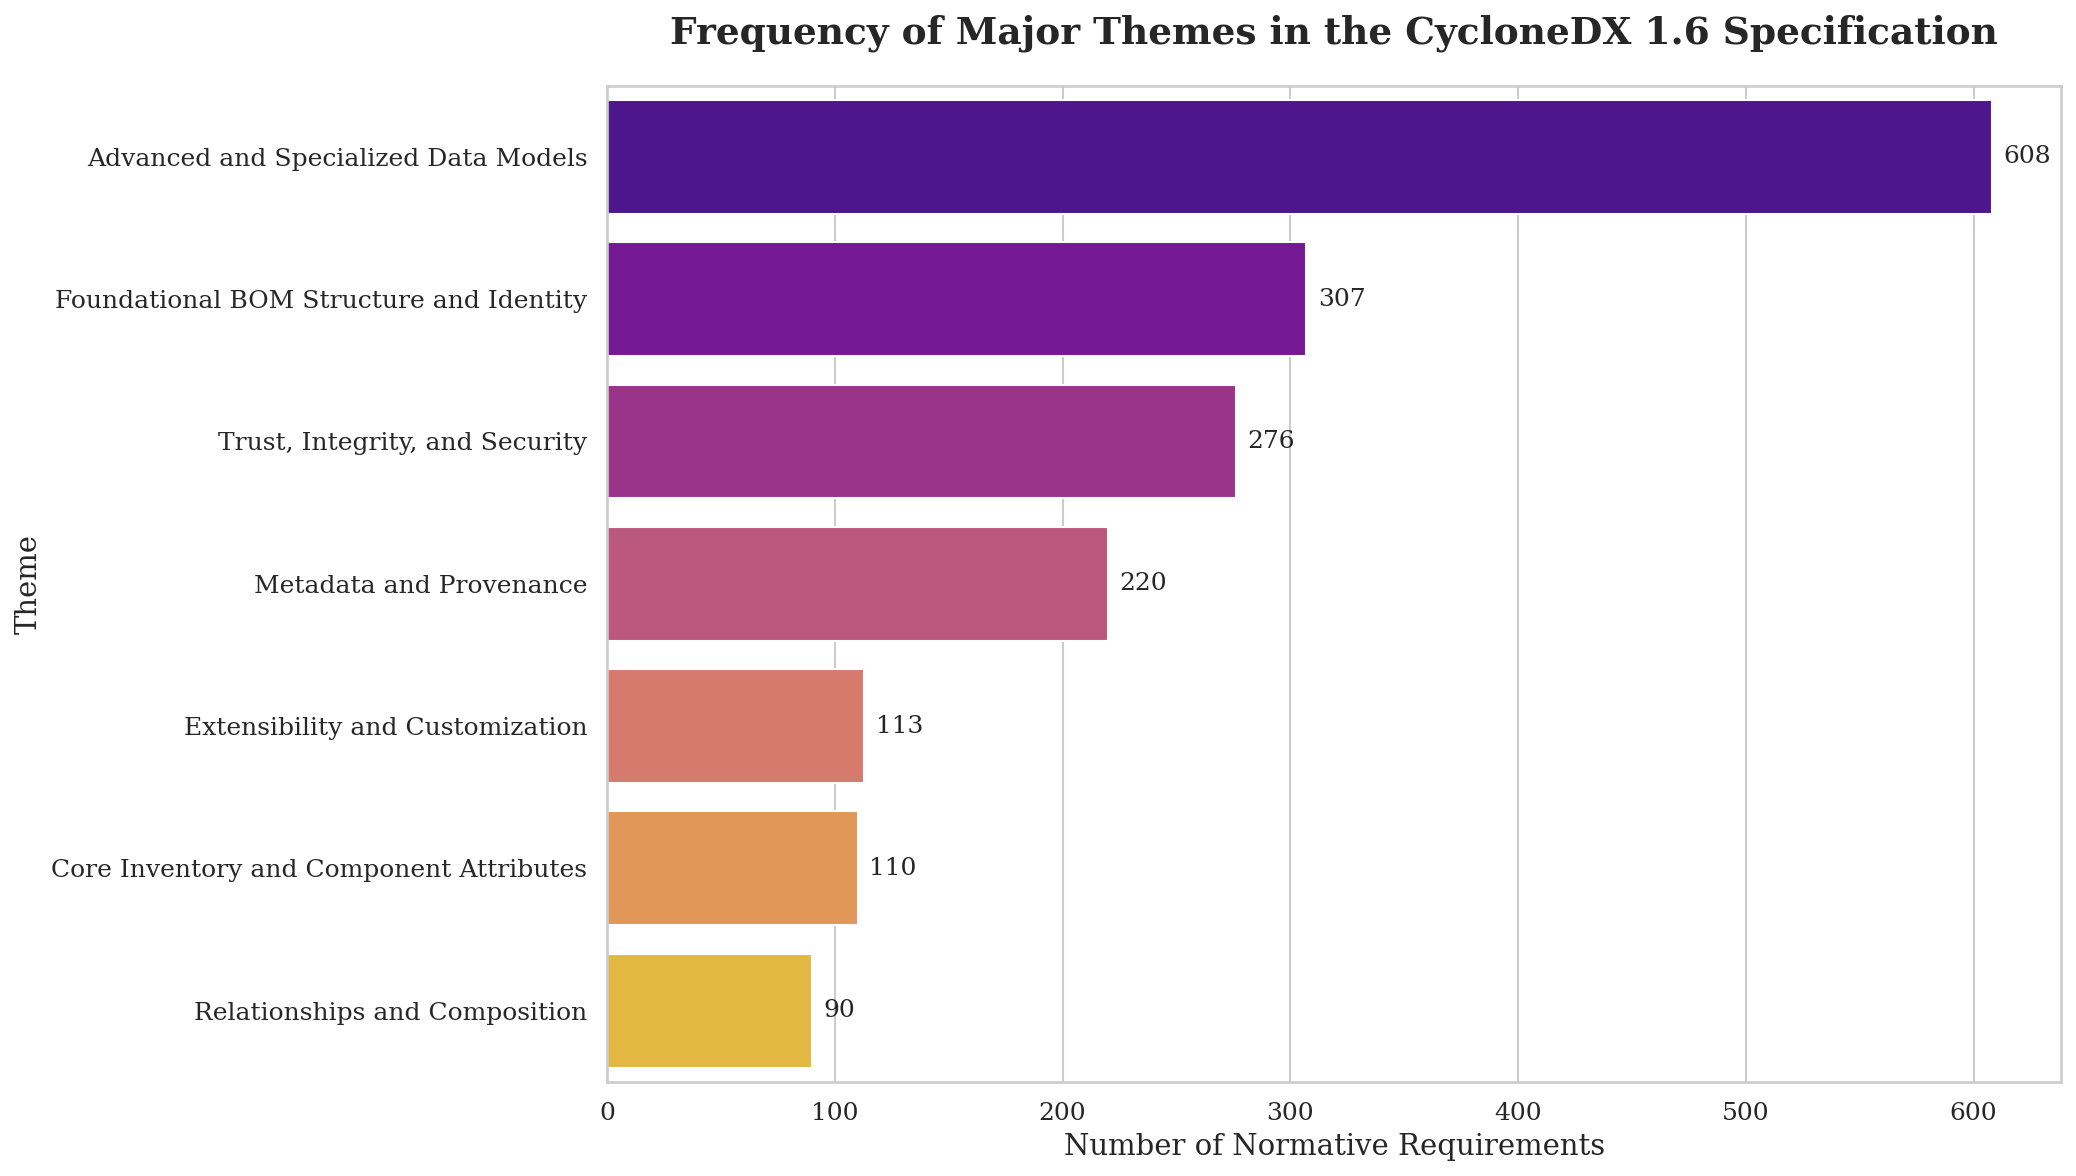

In [4]:
if not df.empty:
    theme_counts = df['Theme'].value_counts()

    plt.figure(figsize=(14, 8))
    ax = sns.barplot(x=theme_counts.values, y=theme_counts.index, palette='plasma', orient='h')
    
    plt.xlabel('Number of Normative Requirements')
    plt.ylabel('Theme')
    plt.title('Frequency of Major Themes in the CycloneDX 1.6 Specification', pad=20, weight='bold')
    
    # Annotate bars with counts
    for i, (p, count) in enumerate(zip(ax.patches, theme_counts.values)):
        ax.text(count + 5, p.get_y() + p.get_height() / 2, f'{count}', ha='left', va='center')

    plt.tight_layout()
    plt.show()


## 5. Granular Subtheme Analysis

We now drill down to the subtheme level. This analysis reveals the specific concepts where the specification provides the most detailed and frequent guidance.


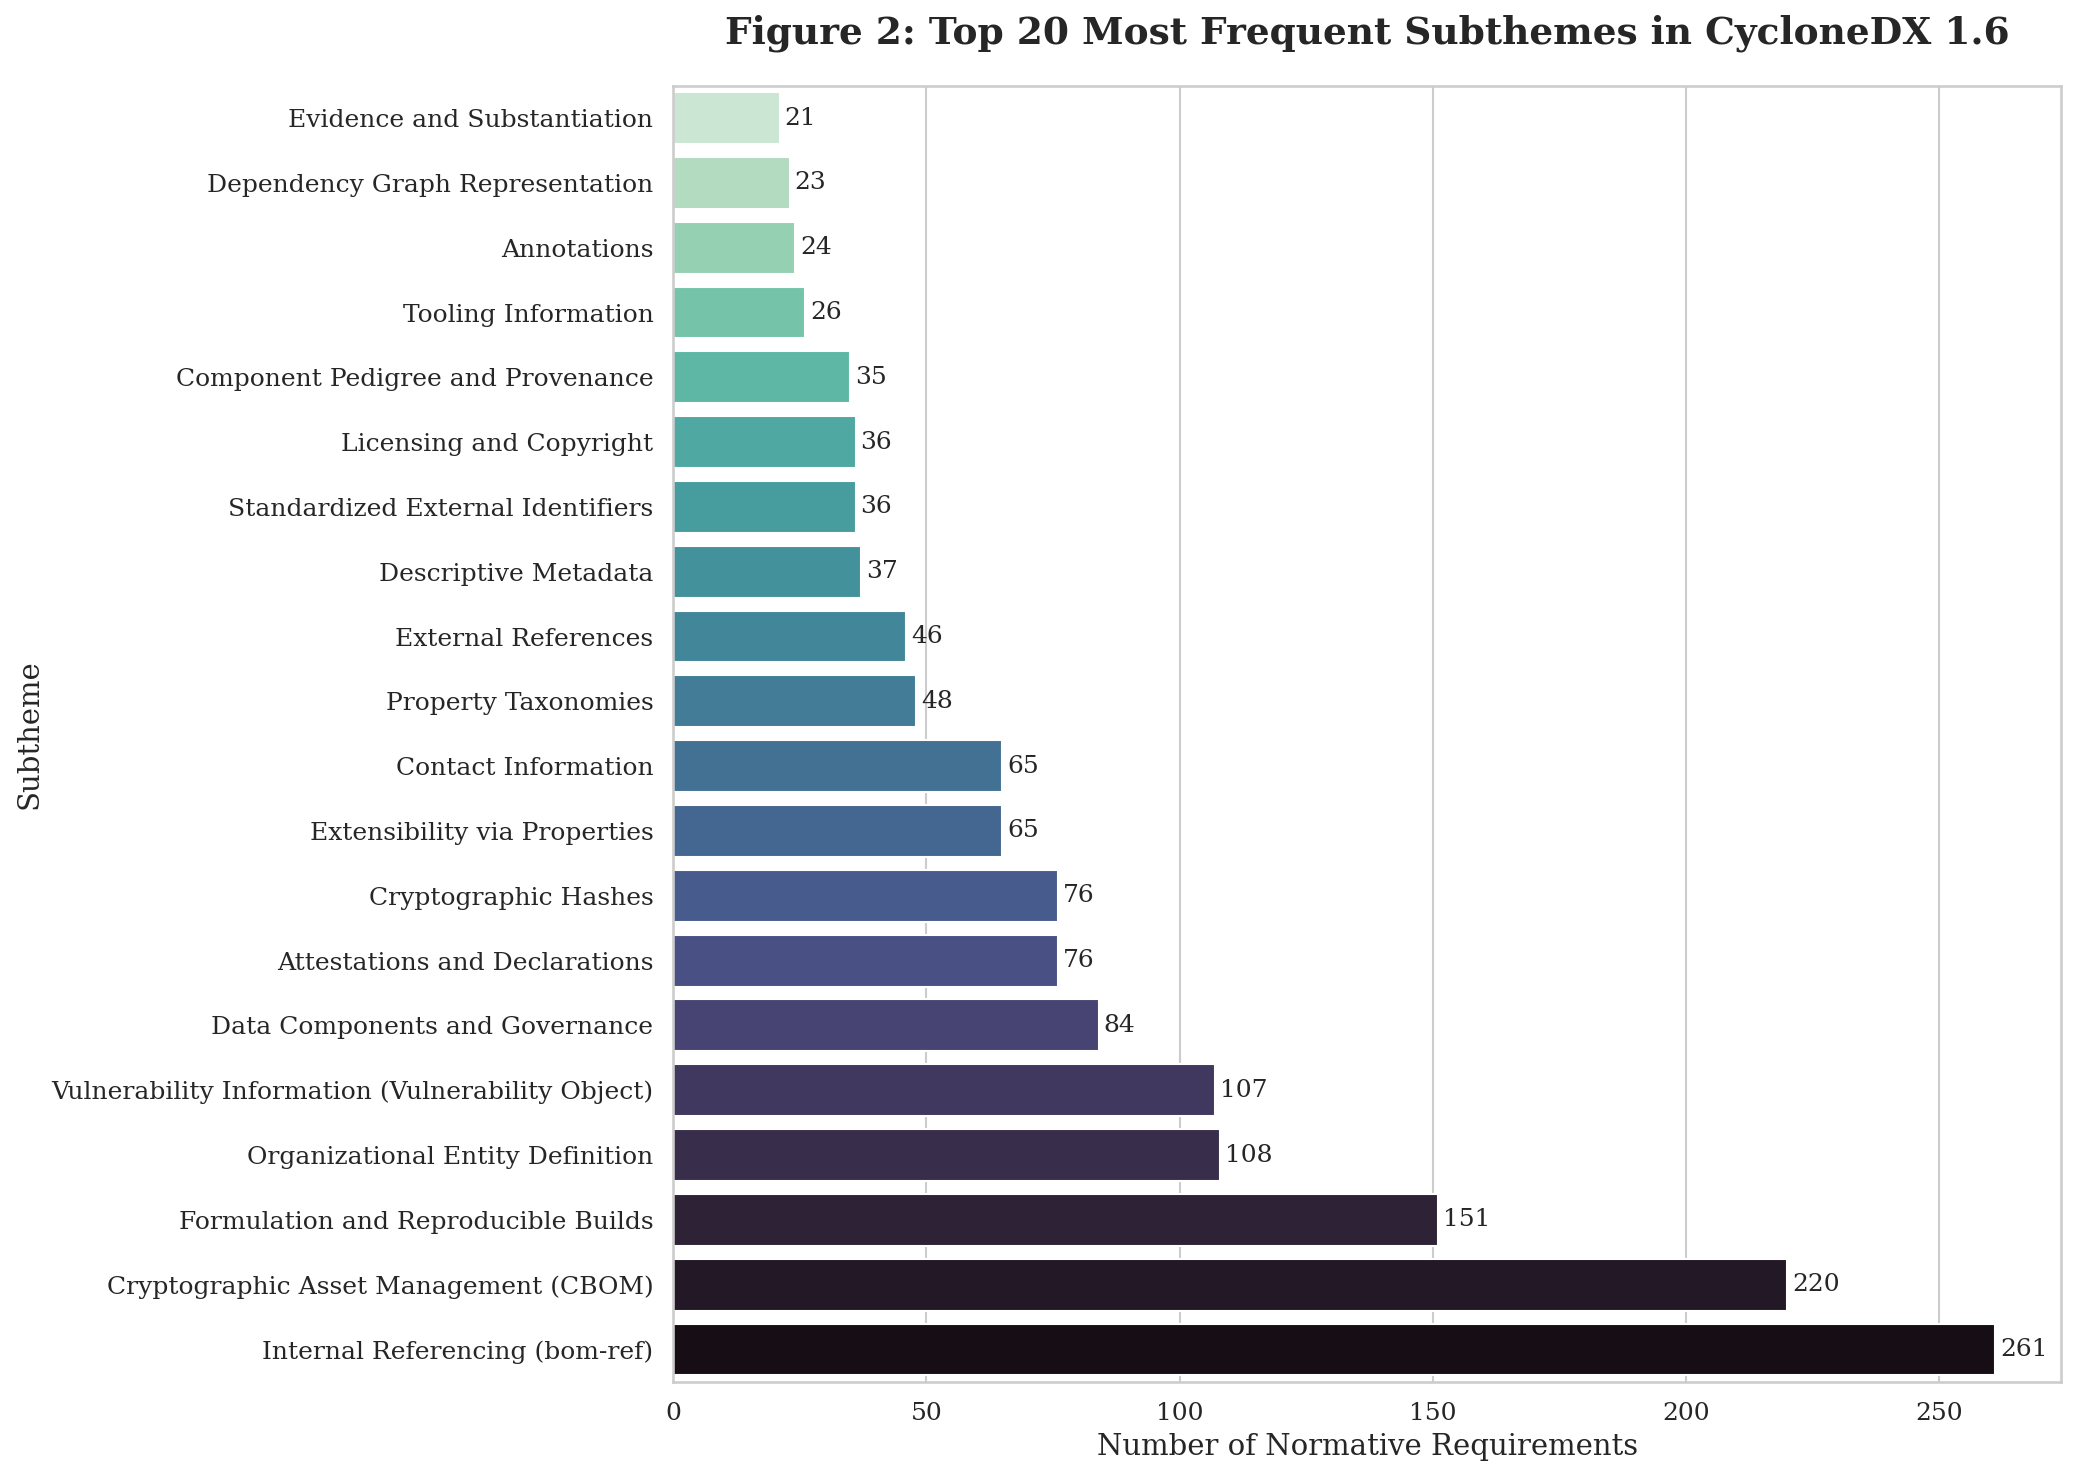

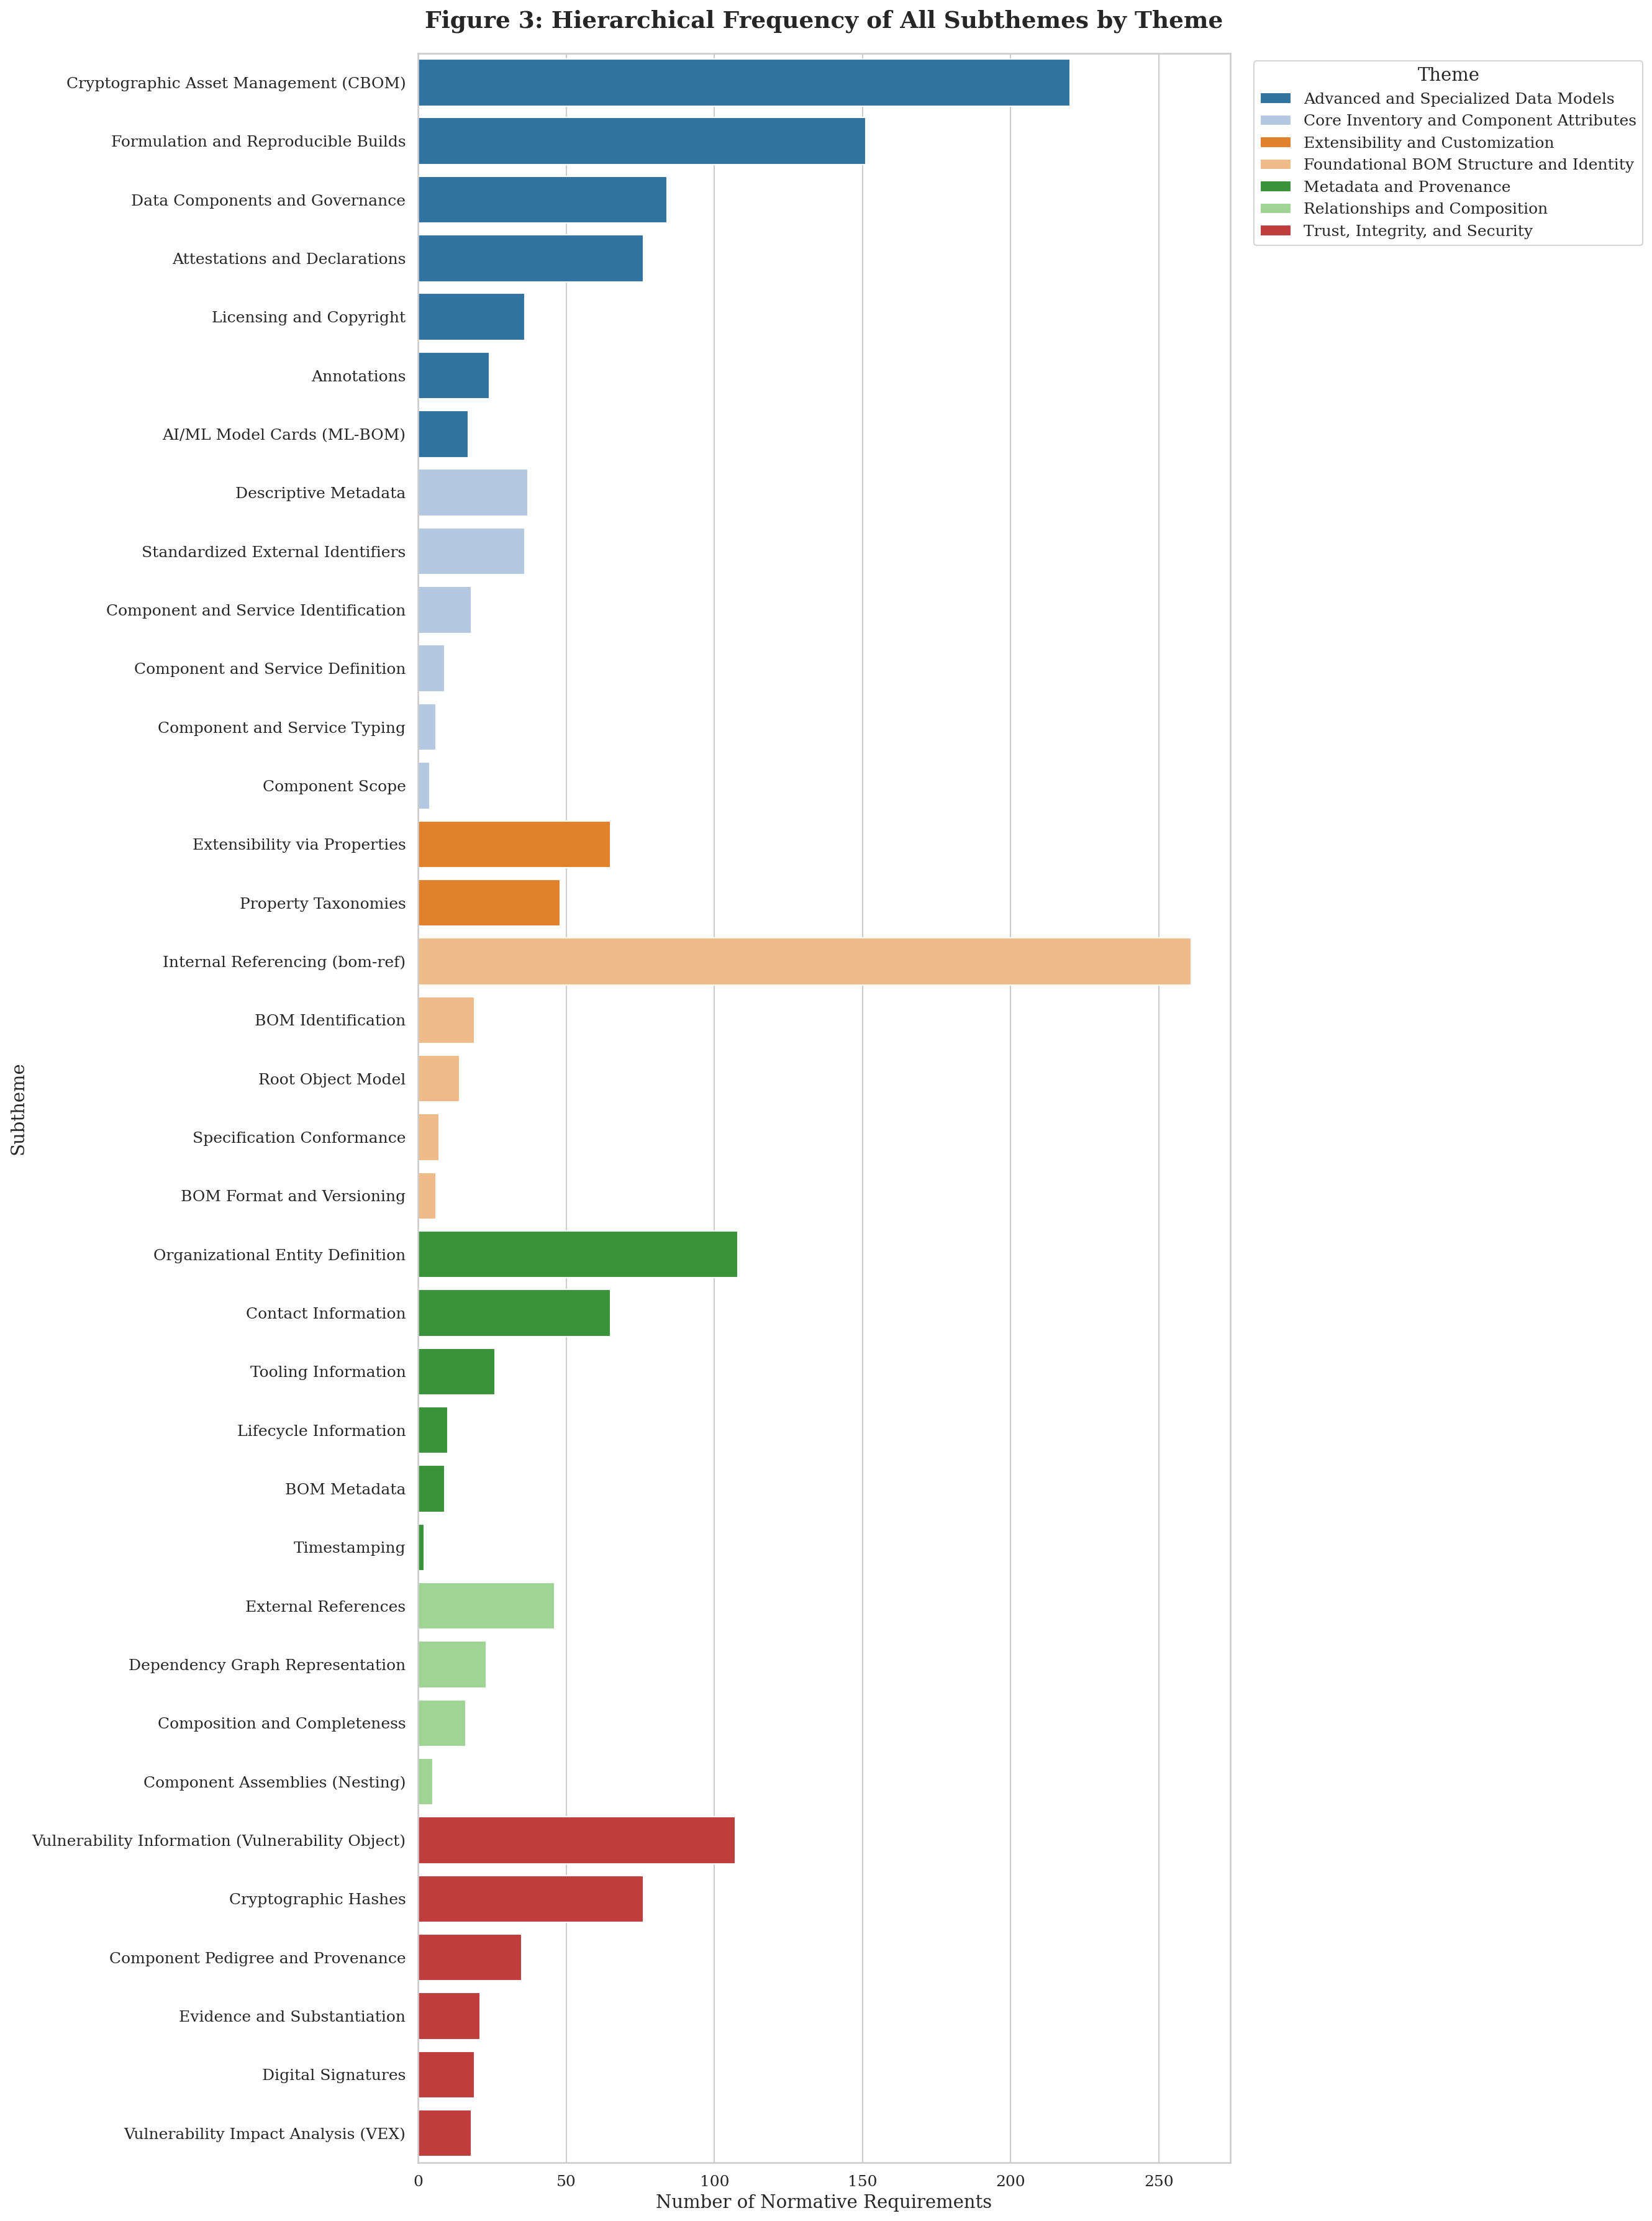

In [5]:
if not df.empty:
    # --- 5.1. Top N Most Frequent Subthemes ---
    top_n = 20
    subtheme_counts = df['Subtheme'].value_counts().nlargest(top_n)

    plt.figure(figsize=(14, 10))
    ax = sns.barplot(x=subtheme_counts.values, y=subtheme_counts.index, palette='mako', orient='h')
    
    plt.xlabel('Number of Normative Requirements')
    plt.ylabel('Subtheme')
    plt.title(f'Figure 2: Top {top_n} Most Frequent Subthemes in CycloneDX 1.6', pad=20, weight='bold')
    
    # Annotate bars
    for i, (p, count) in enumerate(zip(ax.patches, subtheme_counts.values)):
        ax.text(count + 1, p.get_y() + p.get_height() / 2, f'{count}', ha='left', va='center')
        
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    # --- 5.2. Hierarchical Subtheme Distribution (Grouped Bar Chart) ---
    subtheme_grouped = df.groupby(['Theme', 'Subtheme']).size().reset_index(name='Count')
    subtheme_grouped = subtheme_grouped.sort_values(by=['Theme', 'Count'], ascending=[True, False])

    plt.figure(figsize=(18, 24))
    sns.barplot(x='Count', y='Subtheme', data=subtheme_grouped, hue='Theme', dodge=False, palette='tab20')
    
    plt.xlabel('Number of Normative Requirements')
    plt.ylabel('Subtheme')
    plt.title('Figure 3: Hierarchical Frequency of All Subthemes by Theme', pad=20, weight='bold')
    plt.legend(title='Theme', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()


## 6. Normative Force Analysis

This section provides a deep dive into the prescriptive force of the specification by analyzing the distribution and density of `REQUIRED`, `SHOULD`, and `MAY` keywords.


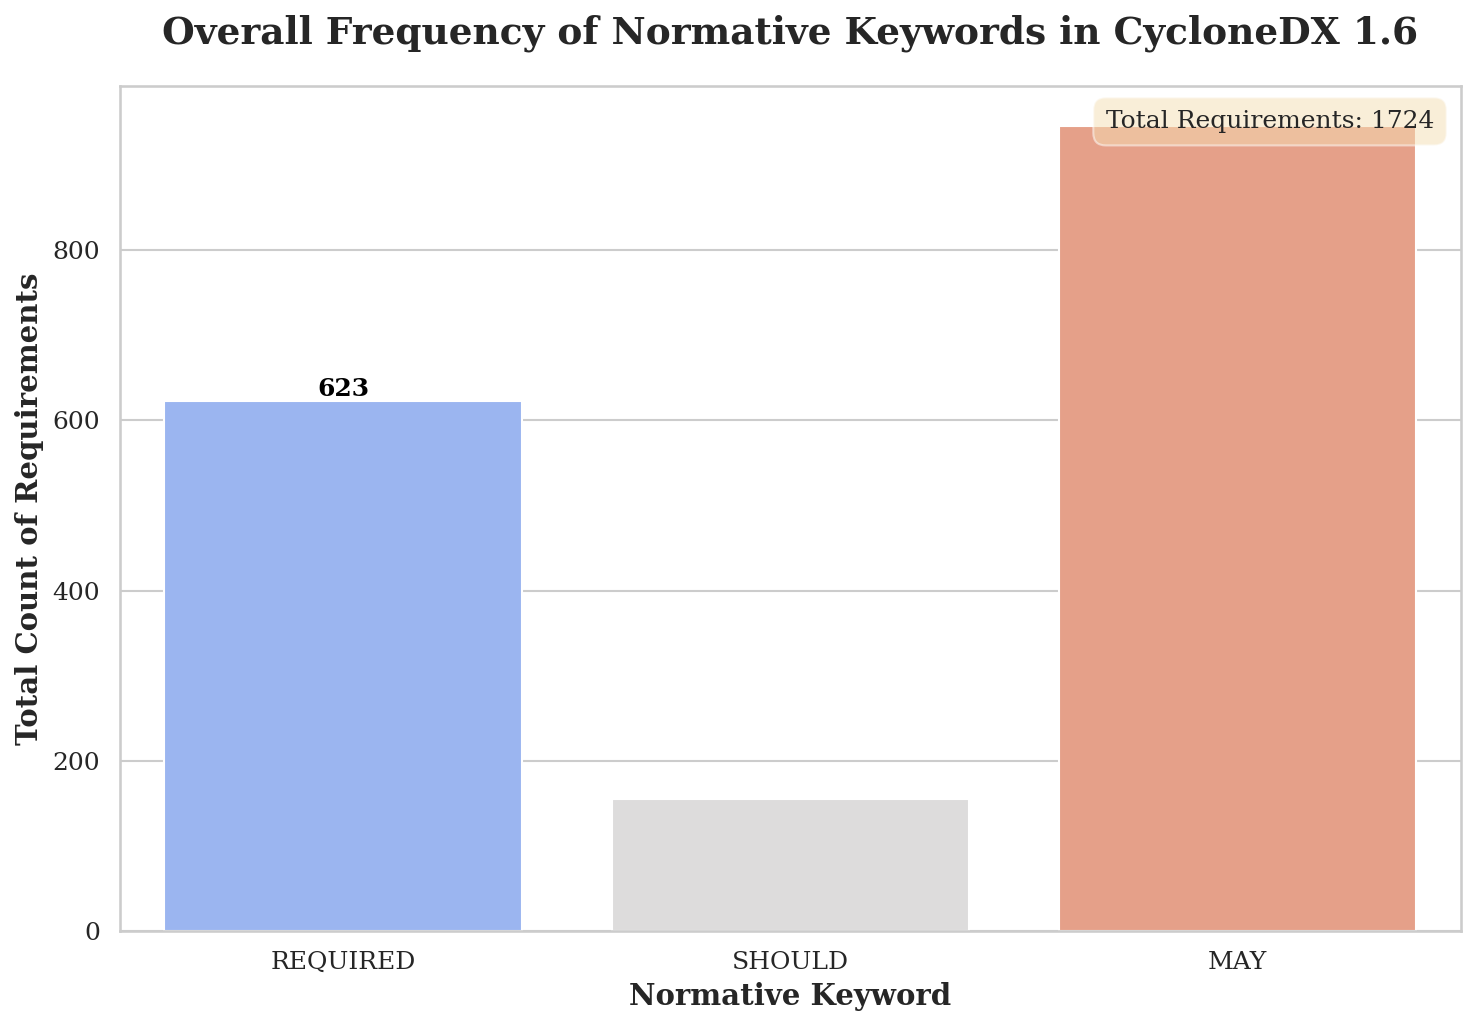

In [6]:
# ## 6. Normative Force Analysis
#
# This section provides a deep dive into the prescriptive force of the specification by analyzing the distribution and density of `REQUIRED`, `SHOULD`, and `MAY` keywords.

# In[6]:


if not df.empty:
    keyword_order = ['REQUIRED', 'SHOULD', 'MAY']
    
    # --- 6.1. Bar Chart for Overall Keyword Distribution ---
    # This provides a clear, direct comparison of the frequency of each keyword category.
    keyword_counts = df['Standard_Keyword'].value_counts().reindex(keyword_order).fillna(0)
    
    plt.figure(figsize=(10, 7))
    ax = sns.barplot(x=keyword_counts.index, 
                     y=keyword_counts.values, 
                     palette='coolwarm',
                     order=keyword_order)
    
    # Add labels and title for clarity and publication readiness
    plt.xlabel('Normative Keyword', weight='bold')
    plt.ylabel('Total Count of Requirements', weight='bold')
    plt.title('Overall Frequency of Normative Keywords in CycloneDX 1.6', 
              pad=20, 
              weight='bold', 
              fontsize=18)
    
    # Add data labels on top of each bar for precise numbers
    ax.bar_label(ax.containers[0], fmt='%d', fontsize=12, weight='bold', color='black')
    
    # Add a total count annotation for context
    total_reqs = len(df)
    plt.text(0.98, 0.95, f'Total Requirements: {total_reqs}', 
             transform=ax.transAxes, 
             horizontalalignment='right',
             fontsize=12, 
             bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
             
    plt.tight_layout()
    plt.show()

    # --- 6.2. Detailed Keyword Distribution Across Themes (Absolute and Proportional) ---
    # This visualization remains unchanged as it is already a robust analysis.
    distribution = pd.crosstab(df['Theme'], df['Standard_Keyword'])
    distribution = distribution.reindex(columns=keyword_order, fill_value=0)
    distribution_percentage = distribution.div(distribution.sum(axis=1), axis=0) * 100

    fig = make_subplots(rows=1, cols=2, subplot_titles=('<b>Absolute Counts</b>', '<b>Proportional Distribution (%)</b>'))

    colors = {'REQUIRED': 'rgb(215, 48, 39)', 'SHOULD': 'rgb(254, 224, 144)', 'MAY': 'rgb(69, 117, 180)'}

    for keyword in keyword_order:
        fig.add_trace(go.Bar(
            y=distribution.index,
            x=distribution[keyword],
            name=keyword,
            orientation='h',
            marker_color=colors[keyword]
        ), row=1, col=1)
        
        fig.add_trace(go.Bar(
            y=distribution_percentage.index,
            x=distribution_percentage[keyword],
            name=keyword,
            orientation='h',
            marker_color=colors[keyword],
            showlegend=False  # Avoid duplicate legend entries
        ), row=1, col=2)

    fig.update_layout(
        barmode='stack',
        title_text='<b>Figure 5: Normative Keyword Distribution Across Themes</b>',
        title_x=0.5,
        height=700,
        yaxis={'categoryorder': 'total ascending'},
        yaxis2={'categoryorder': 'total ascending'}
    )
    fig.update_xaxes(title_text="Number of Requirements", row=1, col=1)
    fig.update_xaxes(title_text="Percentage of Requirements (%)", row=1, col=2)
    fig.show()

## 7. Hierarchical and Relational Visualizations

We now use advanced visualizations to explore the taxonomy's structure, showing the relationships and relative importance of different concepts within the standard.


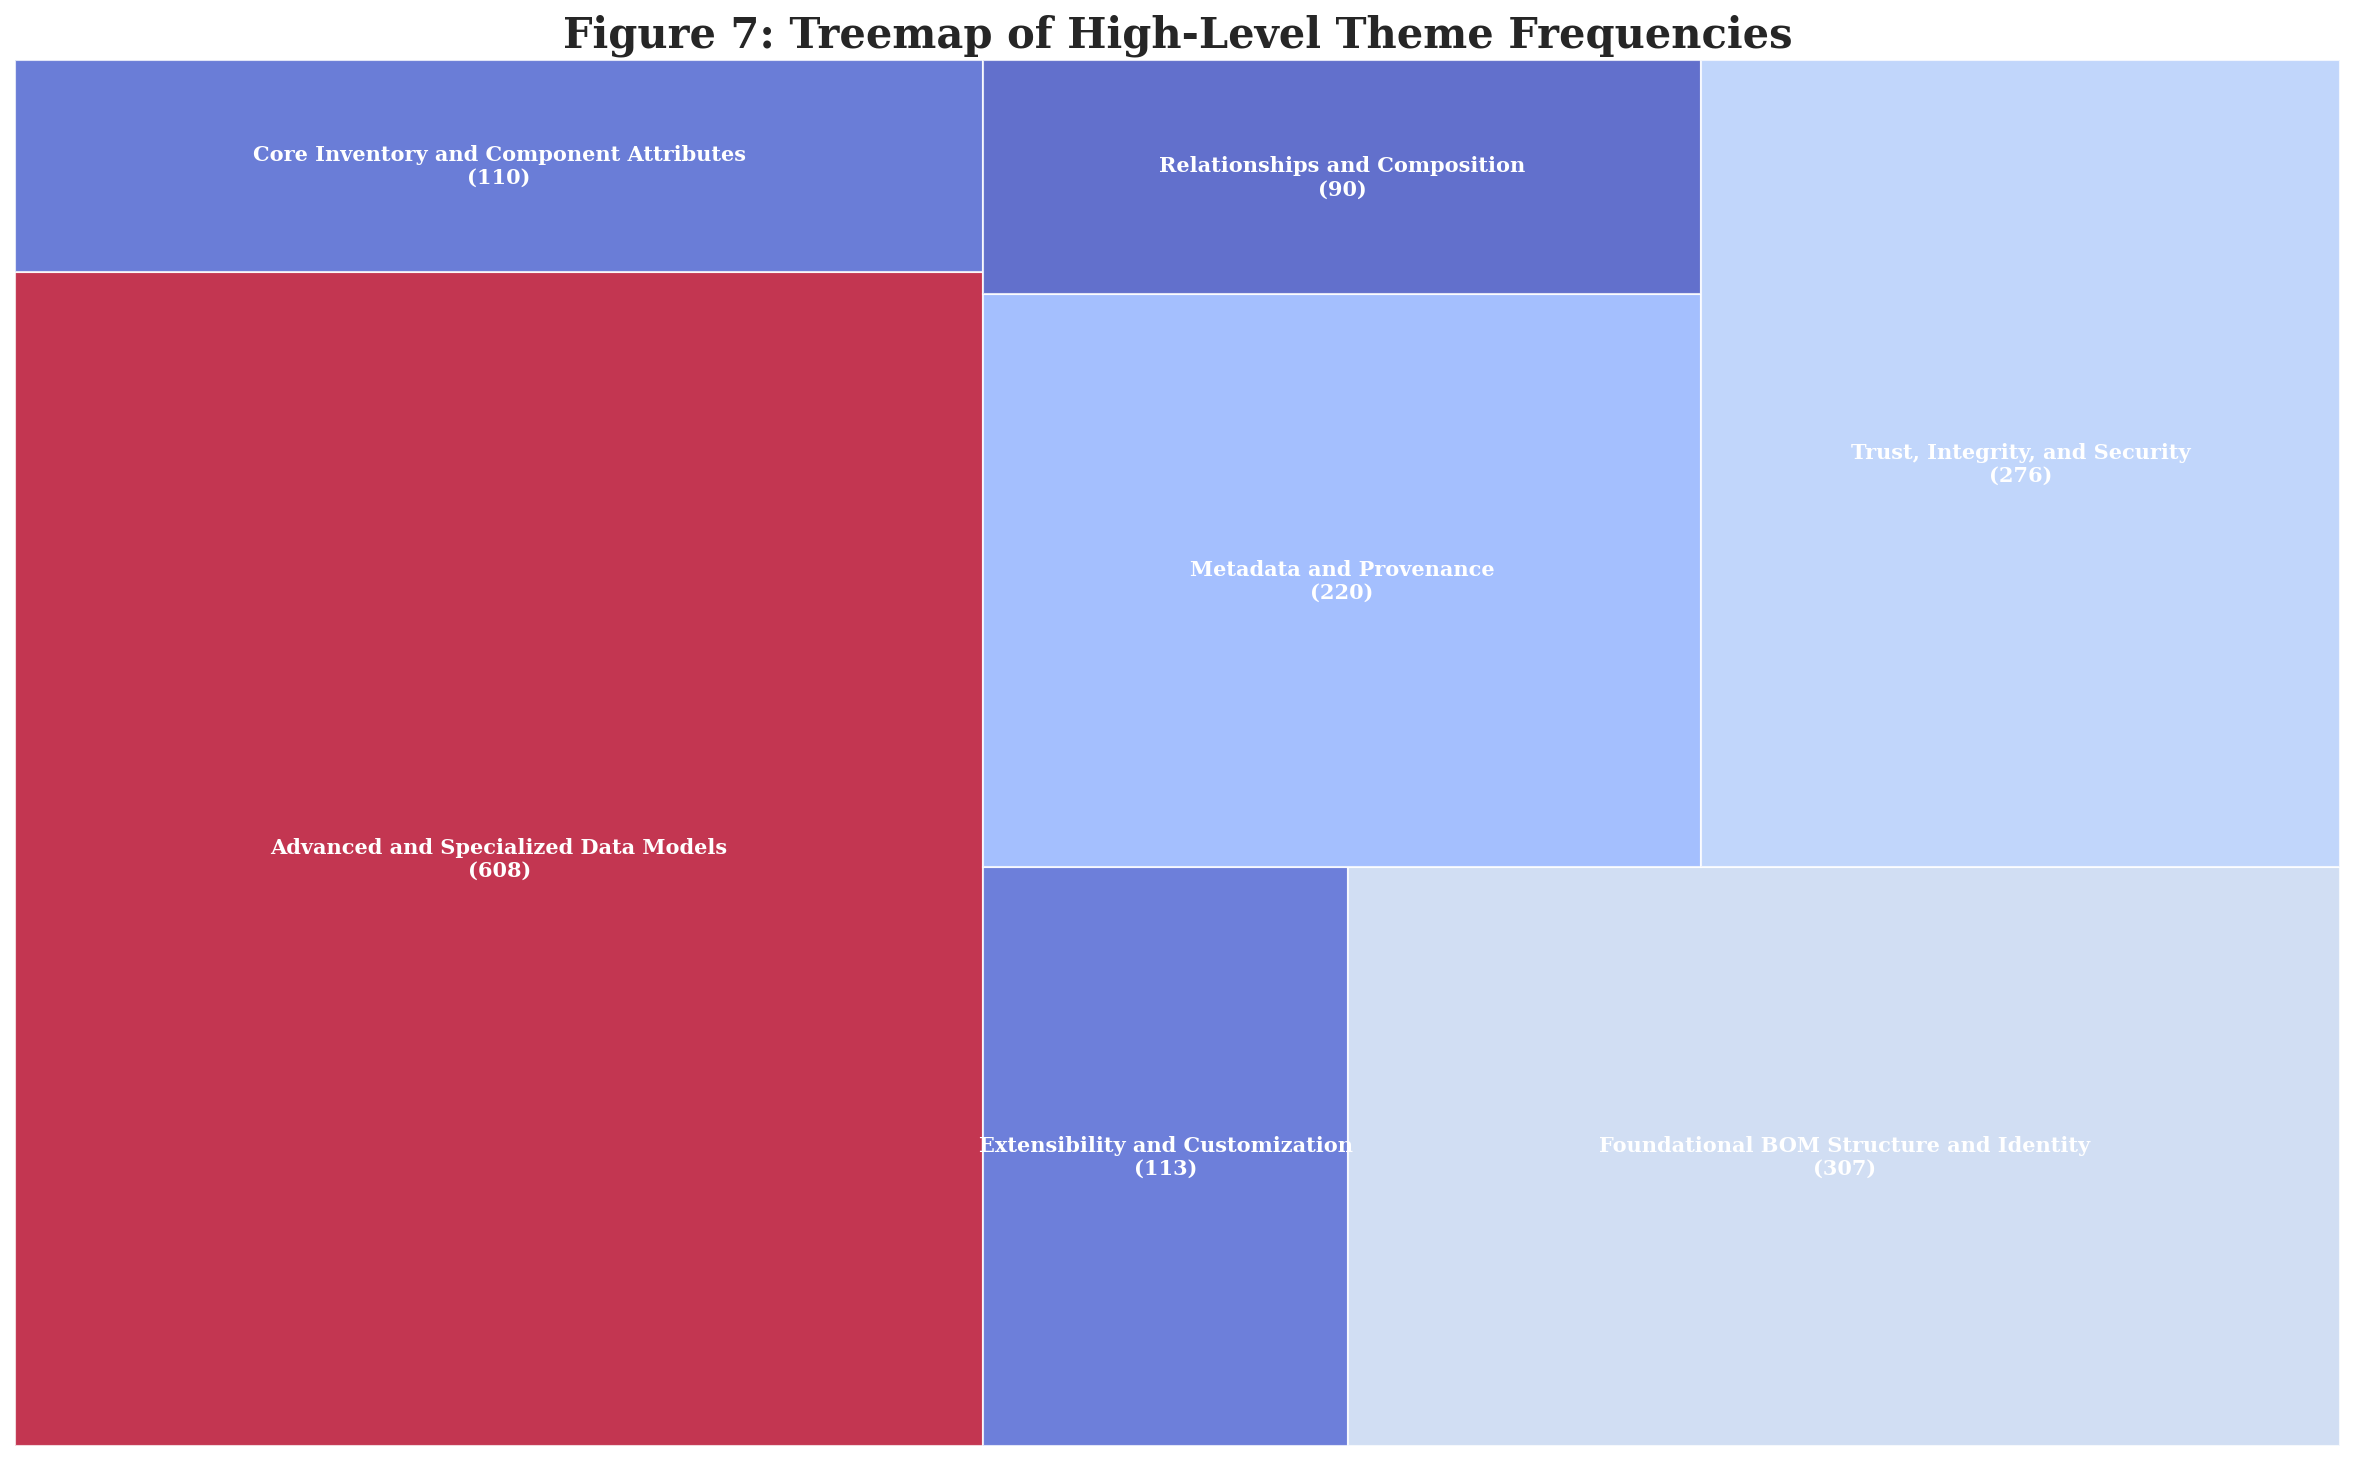

✅ Graphviz tree diagram generated. Displaying below.


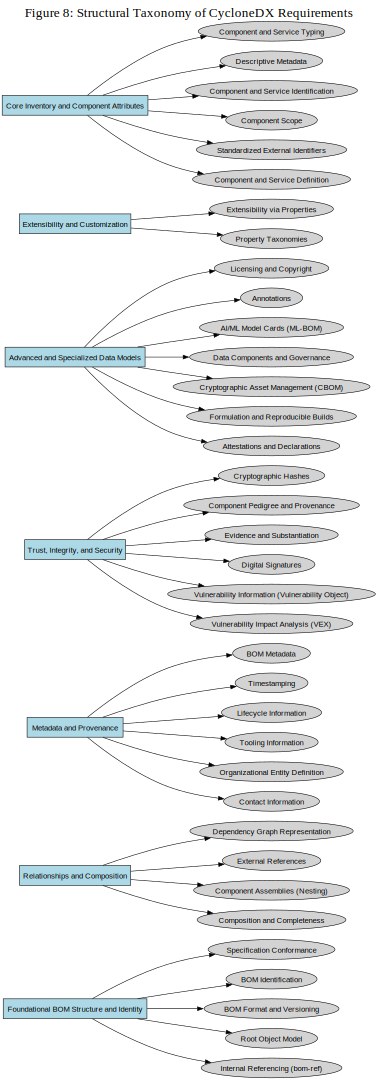

In [7]:
if not df.empty:
    # --- 7.1. Interactive Sunburst Chart for Taxonomy Exploration ---
    fig = px.sunburst(df,
                      path=[px.Constant("CycloneDX v1.6"), 'Theme', 'Subtheme'],
                      values='ID',  # Use a placeholder column to get counts
                      title='<b>Figure 6: Interactive Hierarchical Sunburst of CycloneDX Requirements</b>',
                      color='Theme',
                      color_discrete_sequence=px.colors.qualitative.Plotly,
                      maxdepth=2)

    fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
    fig.update_traces(textinfo='label+percent entry', insidetextorientation='radial')
    fig.show()

    # --- 7.2. Static Treemap (Squarify) for Publication ---
    plt.figure(figsize=(20, 12))
    theme_counts = df.groupby('Theme').size().reset_index(name='count')
    
    # Normalize counts for color mapping
    norm = plt.Normalize(vmin=theme_counts['count'].min(), vmax=theme_counts['count'].max())
    colors = [plt.cm.coolwarm(norm(value)) for value in theme_counts['count']]
    
    squarify.plot(
        sizes=theme_counts['count'], 
        label=[f"{name}\n({count})" for name, count in zip(theme_counts['Theme'], theme_counts['count'])],
        alpha=.8,
        color=colors,
        text_kwargs={'fontsize':10, 'color':'white', 'weight':'bold'}
    )
                  
    plt.title('Figure 7: Treemap of High-Level Theme Frequencies', fontsize=20, weight='bold')
    plt.axis('off')
    plt.show()

    # --- 7.3. Structural Tree Diagram (Graphviz) ---
    dot = graphviz.Digraph('CycloneDX_Taxonomy', comment='Thematic Hierarchy')
    dot.attr(rankdir='LR', size='15,15', label='Figure 8: Structural Taxonomy of CycloneDX Requirements', fontsize='24', labelloc='t')
    dot.attr('node', style='filled', fontname='Helvetica')

    # Add Theme nodes
    for theme in df['Theme'].unique():
        dot.node(theme, theme, shape='box', fillcolor='lightblue')

    # Add Subtheme nodes and edges
    for subtheme in df['Subtheme'].unique():
        dot.node(subtheme, subtheme, shape='ellipse', fillcolor='lightgray')
    
    theme_subtheme_pairs = df[['Theme', 'Subtheme']].drop_duplicates()
    for _, row in theme_subtheme_pairs.iterrows():
        dot.edge(row['Theme'], row['Subtheme'])

    print("✅ Graphviz tree diagram generated. Displaying below.")
    display(dot)


## 8. Exploratory Text Analysis

This final section provides a qualitative glimpse into the language of the specification itself, helping to identify key action words and concepts within the requirements.


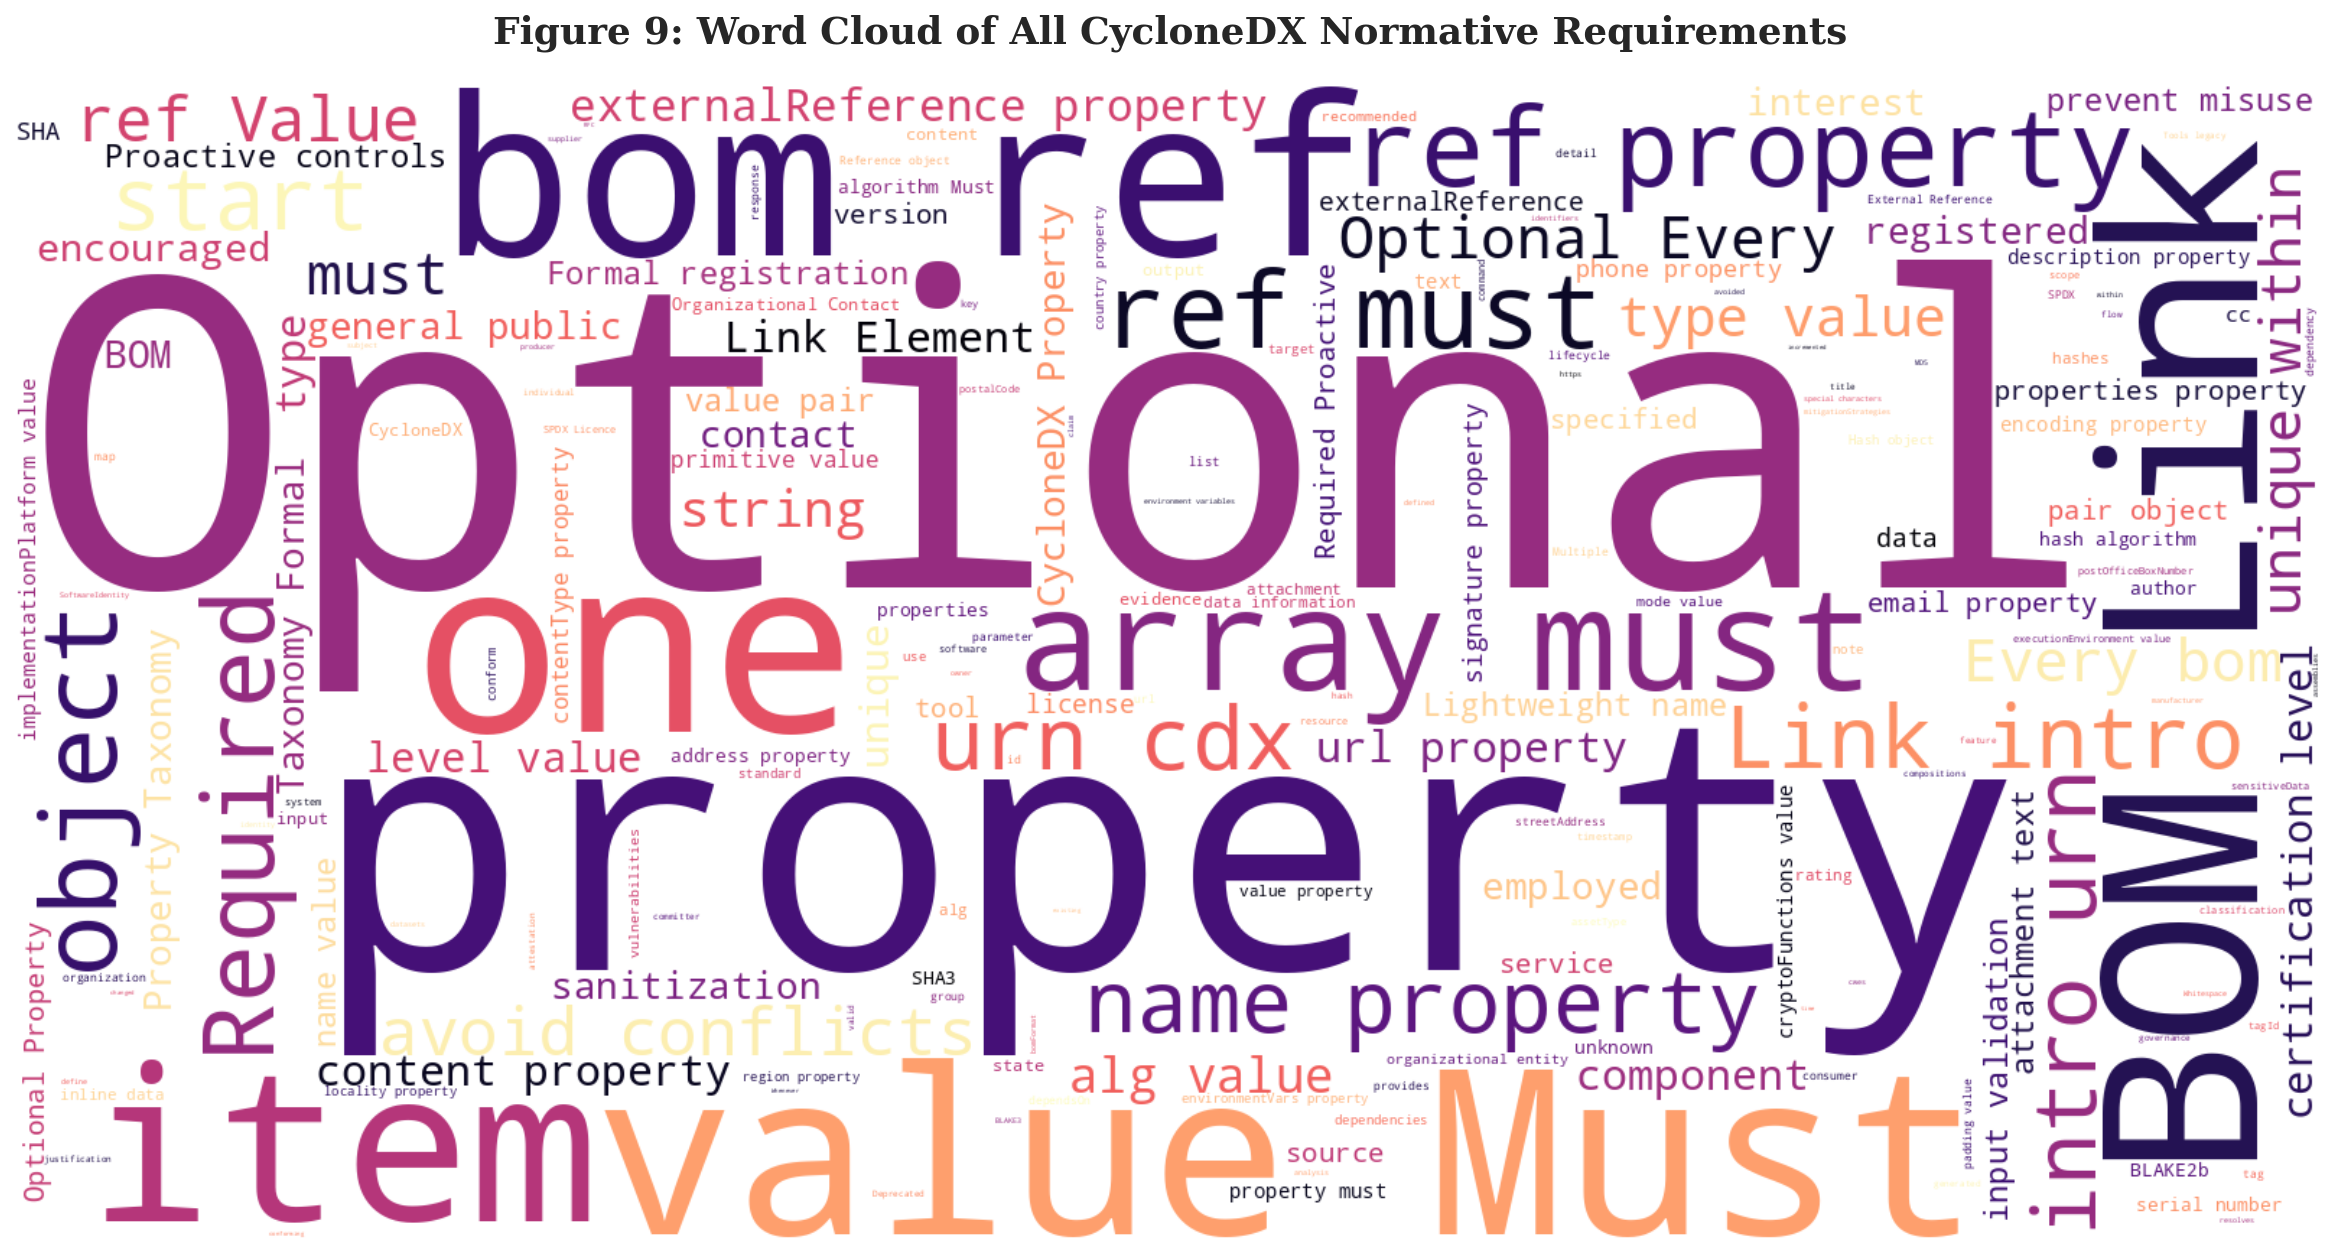

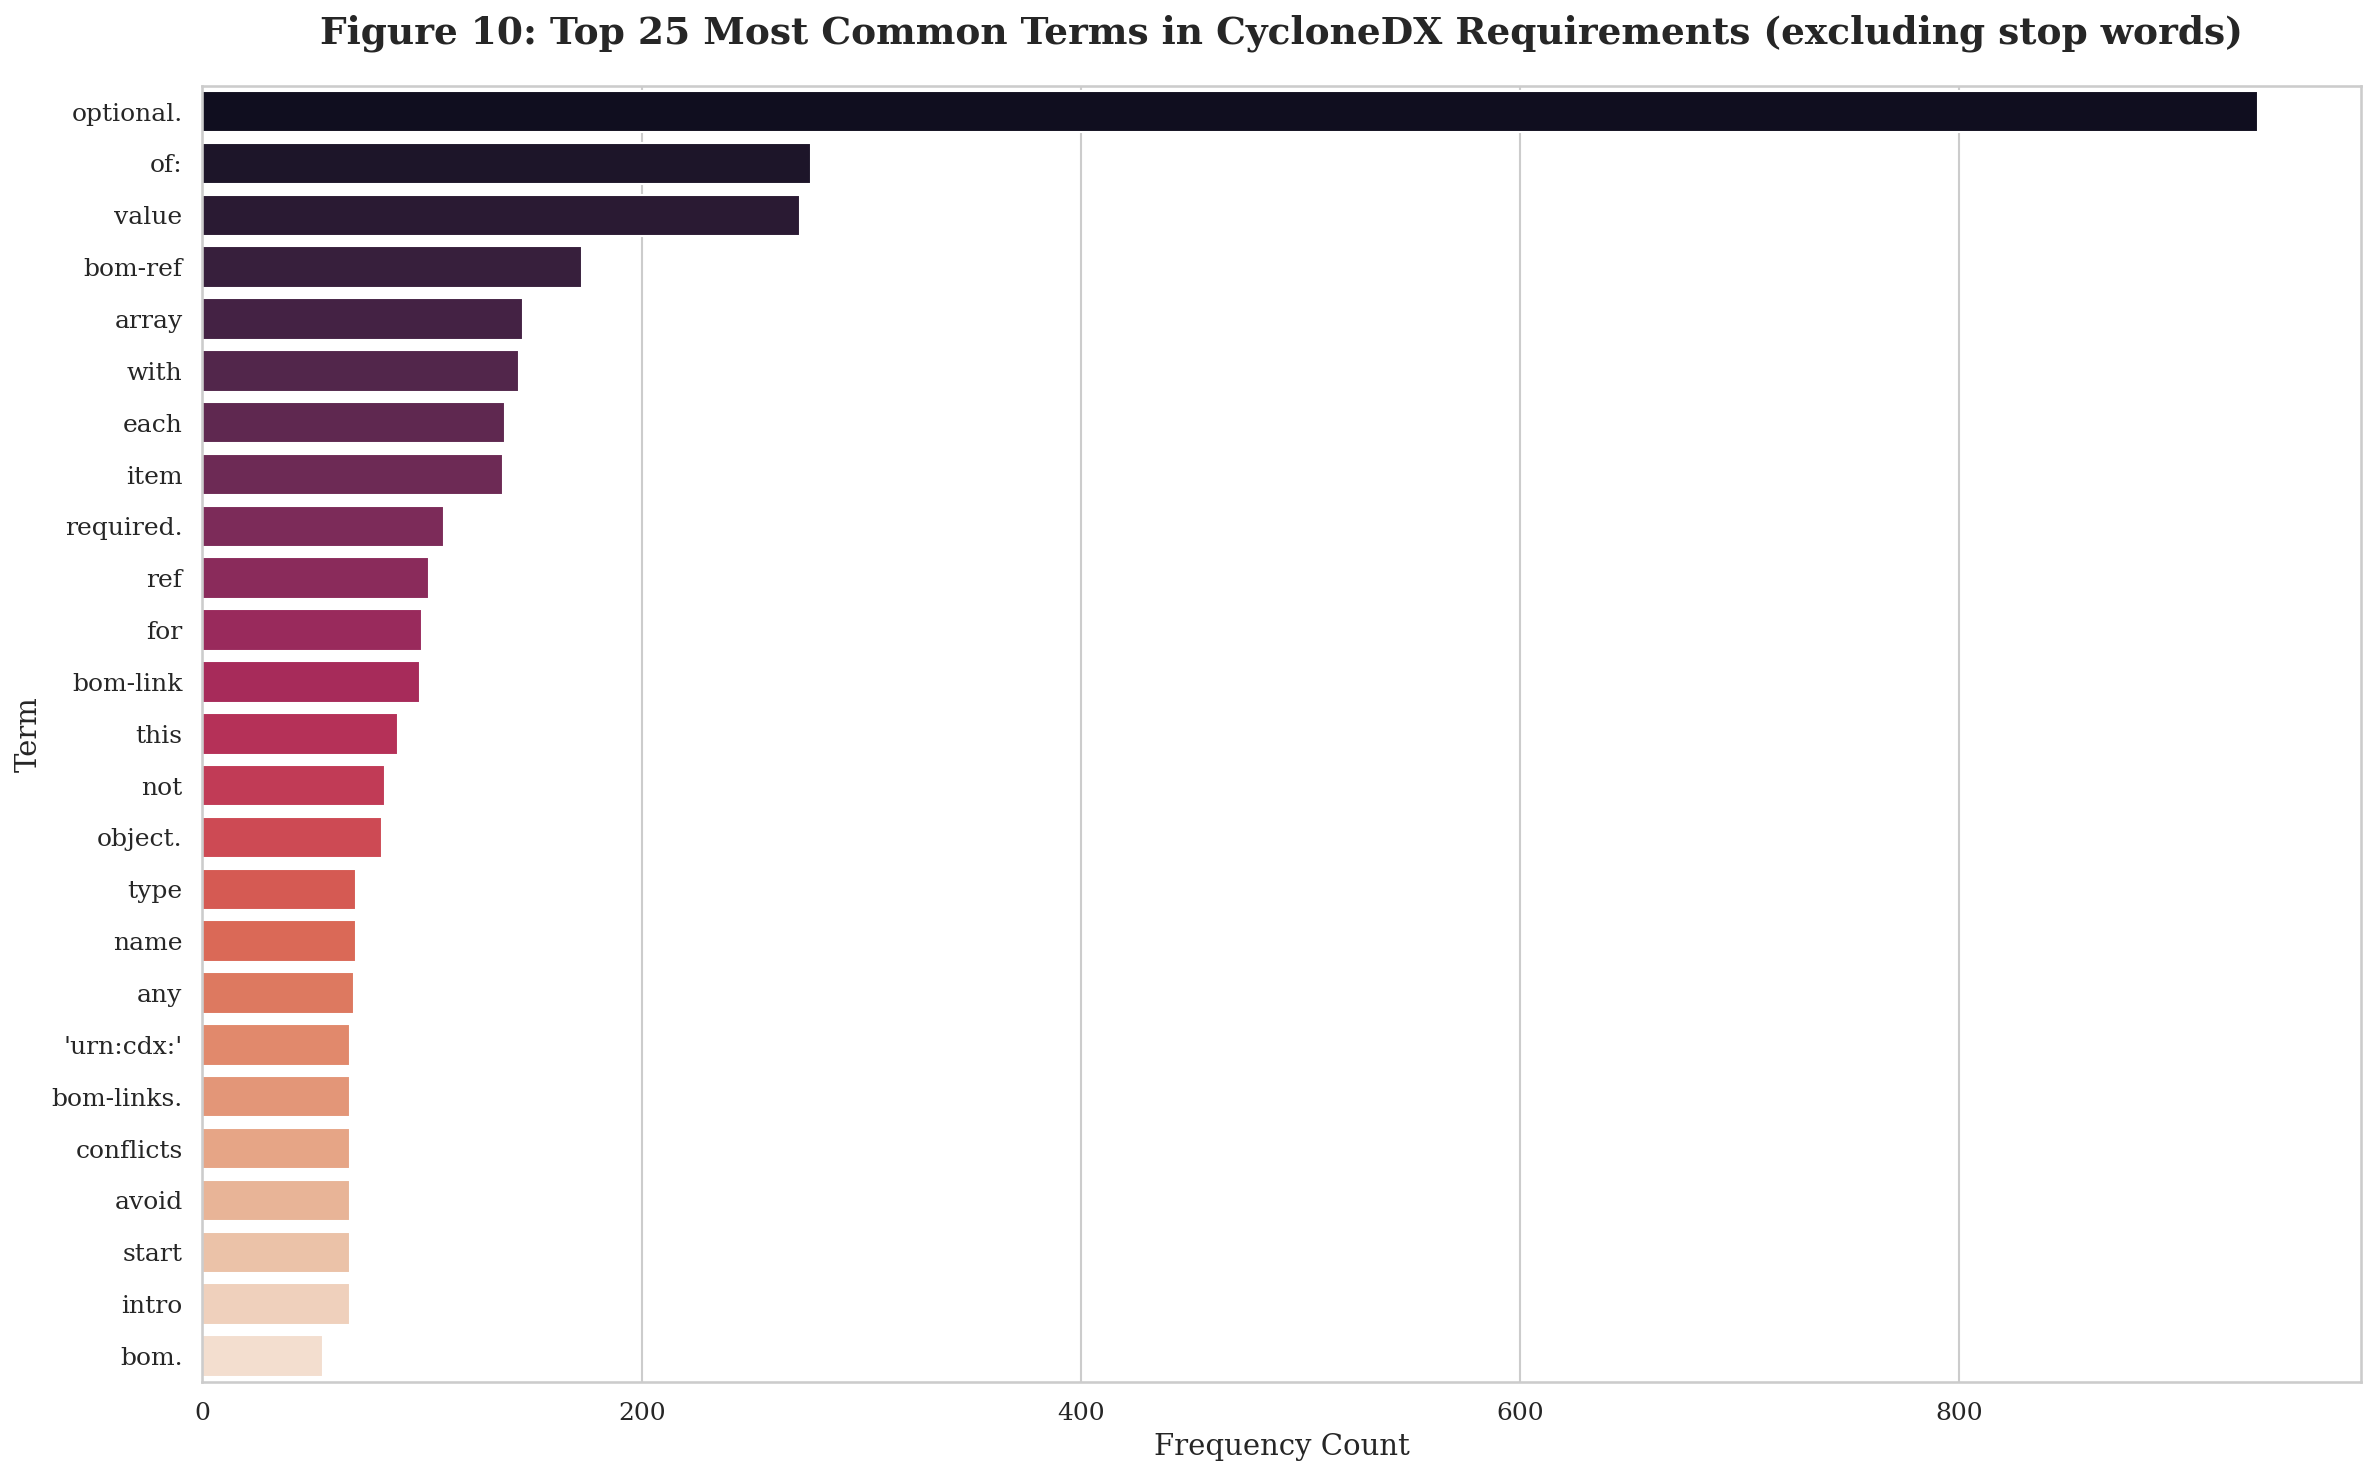

In [8]:
if not df.empty:
    # --- 8.1. Word Cloud of All Requirements ---
    full_text = ' '.join(df['Recommendation / Requirement'])
    
    wordcloud = WordCloud(width=1600, height=800, background_color='white', colormap='magma').generate(full_text)
    
    plt.figure(figsize=(20, 10))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Figure 9: Word Cloud of All CycloneDX Normative Requirements', pad=20, weight='bold')
    plt.show()

    # --- 8.2. Bar Chart of the Most Common Action Verbs/Nouns ---
    # Simple NLP to find common terms (can be enhanced with stop words, stemming, etc.)
    common_words = pd.Series(' '.join(df['Recommendation / Requirement']).lower().split()).value_counts()
    
    # Filter out common stop words and single-character words
    stop_words = ['the', 'is', 'a', 'of', 'be', 'to', 'and', 'must', 'should', 'may', 'one', 'property', 'object']
    common_words = common_words[~common_words.index.isin(stop_words)]
    common_words = common_words[common_words.index.str.len() > 2]
    
    top_words = common_words.head(25)

    plt.figure(figsize=(16, 10))
    sns.barplot(x=top_words.values, y=top_words.index, palette='rocket', orient='h')
    plt.xlabel('Frequency Count')
    plt.ylabel('Term')
    plt.title('Figure 10: Top 25 Most Common Terms in CycloneDX Requirements (excluding stop words)', pad=20, weight='bold')
    plt.tight_layout()
    plt.show()


## 10. Normative Strength Index (NKSI)

To quantify the *prescriptive intensity* of each theme, we define a **Normative Keyword Strength Index (NKSI)**:

\[
\text{NKSI} = \frac{2 \times \text{REQUIRED} + 1 \times \text{SHOULD} + 0.5 \times \text{MAY}}{\text{Total Requirements}}
\]

A higher NKSI indicates a stricter and more mandatory emphasis within a given theme.


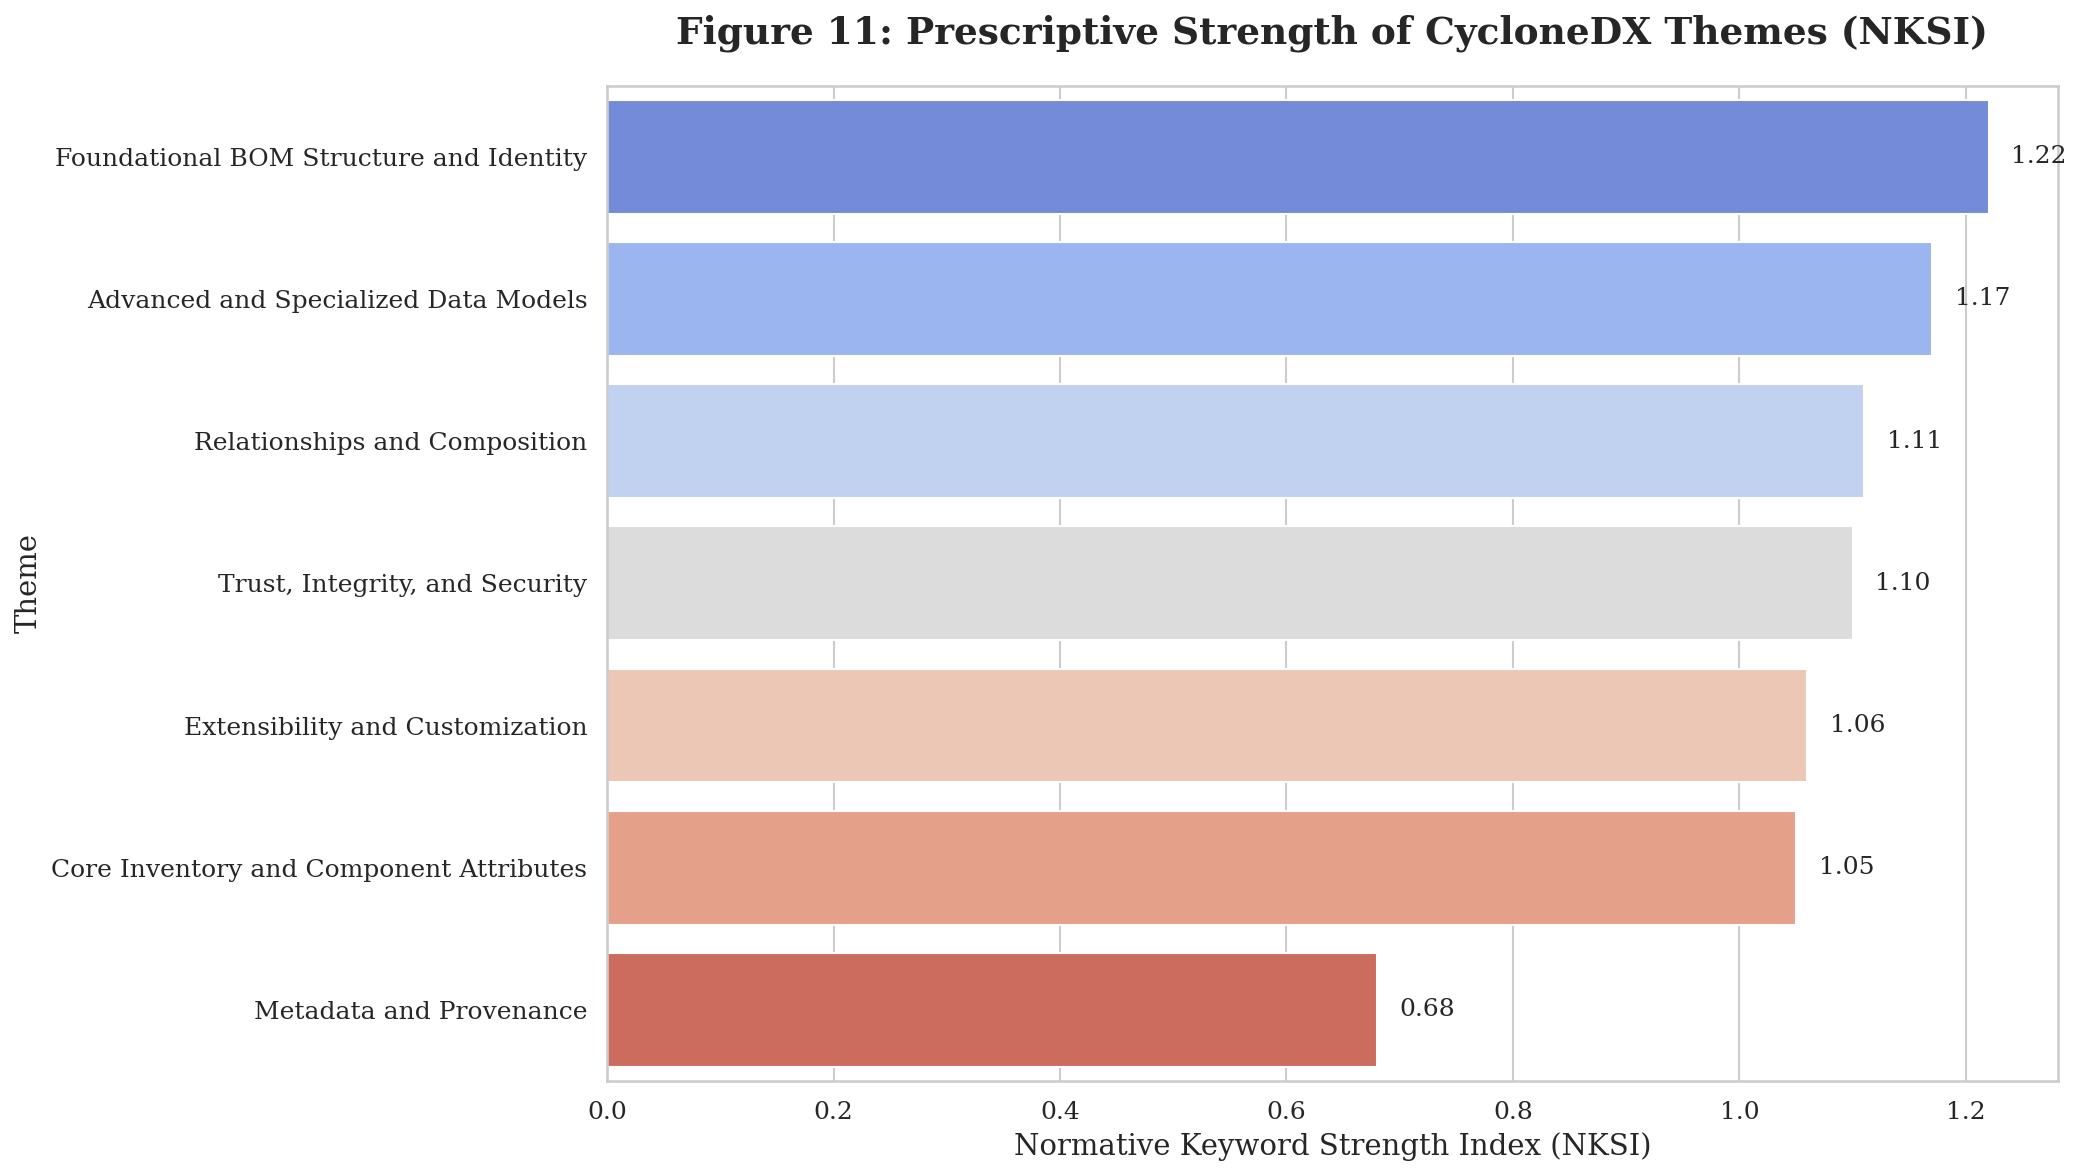

,Theme,sum,count,NKSI
0,Foundational BOM Structure and Identity,373.500000,307,1.22
1,Advanced and Specialized Data Models,712.000000,608,1.17
2,Relationships and Composition,99.500000,90,1.11
3,"Trust, Integrity, and Security",304.000000,276,1.10
4,Extensibility and Customization,119.500000,113,1.06
5,Core Inventory and Component Attributes,115.000000,110,1.05
6,Metadata and Provenance,150.500000,220,0.68


In [9]:
if not df.empty:
    # --- Compute NKSI per theme ---
    weight = {'REQUIRED': 2, 'SHOULD': 1, 'MAY': 0.5}
    df['Weight'] = df['Standard_Keyword'].map(weight)

    nk_df = df.groupby('Theme')['Weight'].agg(['sum', 'count'])
    nk_df['NKSI'] = (nk_df['sum'] / nk_df['count']).round(2)
    nk_df = nk_df.sort_values(by='NKSI', ascending=False).reset_index()

    plt.figure(figsize=(14, 8))
    sns.barplot(x='NKSI', y='Theme', data=nk_df, palette='coolwarm', orient='h')
    plt.xlabel('Normative Keyword Strength Index (NKSI)')
    plt.ylabel('Theme')
    plt.title('Figure 11: Prescriptive Strength of CycloneDX Themes (NKSI)', pad=20, weight='bold')

    # Annotate bars
    for i, (val, name) in enumerate(zip(nk_df['NKSI'], nk_df['Theme'])):
        plt.text(val + 0.02, i, f'{val:.2f}', va='center')

    plt.tight_layout()
    plt.show()

    display(nk_df.style.background_gradient(cmap='coolwarm', subset=['NKSI']).format({'NKSI': '{:.2f}'}))


## 11. Hierarchical Sankey Diagram

The Sankey diagram visualizes how **normative force flows through the CycloneDX hierarchy**, connecting Themes → Subthemes → Normative Keywords.

This representation highlights where prescriptive emphasis is concentrated in the standard.


In [10]:
if not df.empty:
    # --- Prepare Sankey structure ---
    sankey_df = df.groupby(['Theme', 'Subtheme', 'Standard_Keyword']).size().reset_index(name='Count')

    # Create unique label list
    themes = sankey_df['Theme'].unique().tolist()
    subthemes = sankey_df['Subtheme'].unique().tolist()
    keywords = sankey_df['Standard_Keyword'].unique().tolist()

    labels = themes + subthemes + keywords
    theme_offset = 0
    subtheme_offset = len(themes)
    keyword_offset = len(themes) + len(subthemes)

    # Build Sankey links
    source, target, value = [], [], []
    for _, row in sankey_df.iterrows():
        s = labels.index(row['Theme'])
        t = labels.index(row['Subtheme'])
        k = labels.index(row['Standard_Keyword'])
        source.extend([s, t])
        target.extend([t, k])
        value.extend([row['Count'], row['Count']])

    # Create Sankey chart
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=20,
            thickness=20,
            line=dict(color='black', width=0.5),
            label=labels,
            color=['#74add1'] * len(themes) + ['#abd9e9'] * len(subthemes) + ['#fdae61'] * len(keywords)
        ),
        link=dict(source=source, target=target, value=value)
    )])

    fig.update_layout(title_text='<b>Figure 12: Normative Flow Across CycloneDX Taxonomy (Theme → Subtheme → Keyword)</b>', font_size=12)
    fig.show()


## 12. Semantic Clustering of Requirements (TF-IDF + UMAP)

This section explores **linguistic similarity** among CycloneDX requirements.  
We project textual embeddings of each requirement (using TF-IDF + UMAP) into a 2D semantic space.

Each point = one requirement; color = its Theme.  
Clusters reveal conceptually similar areas in the specification.


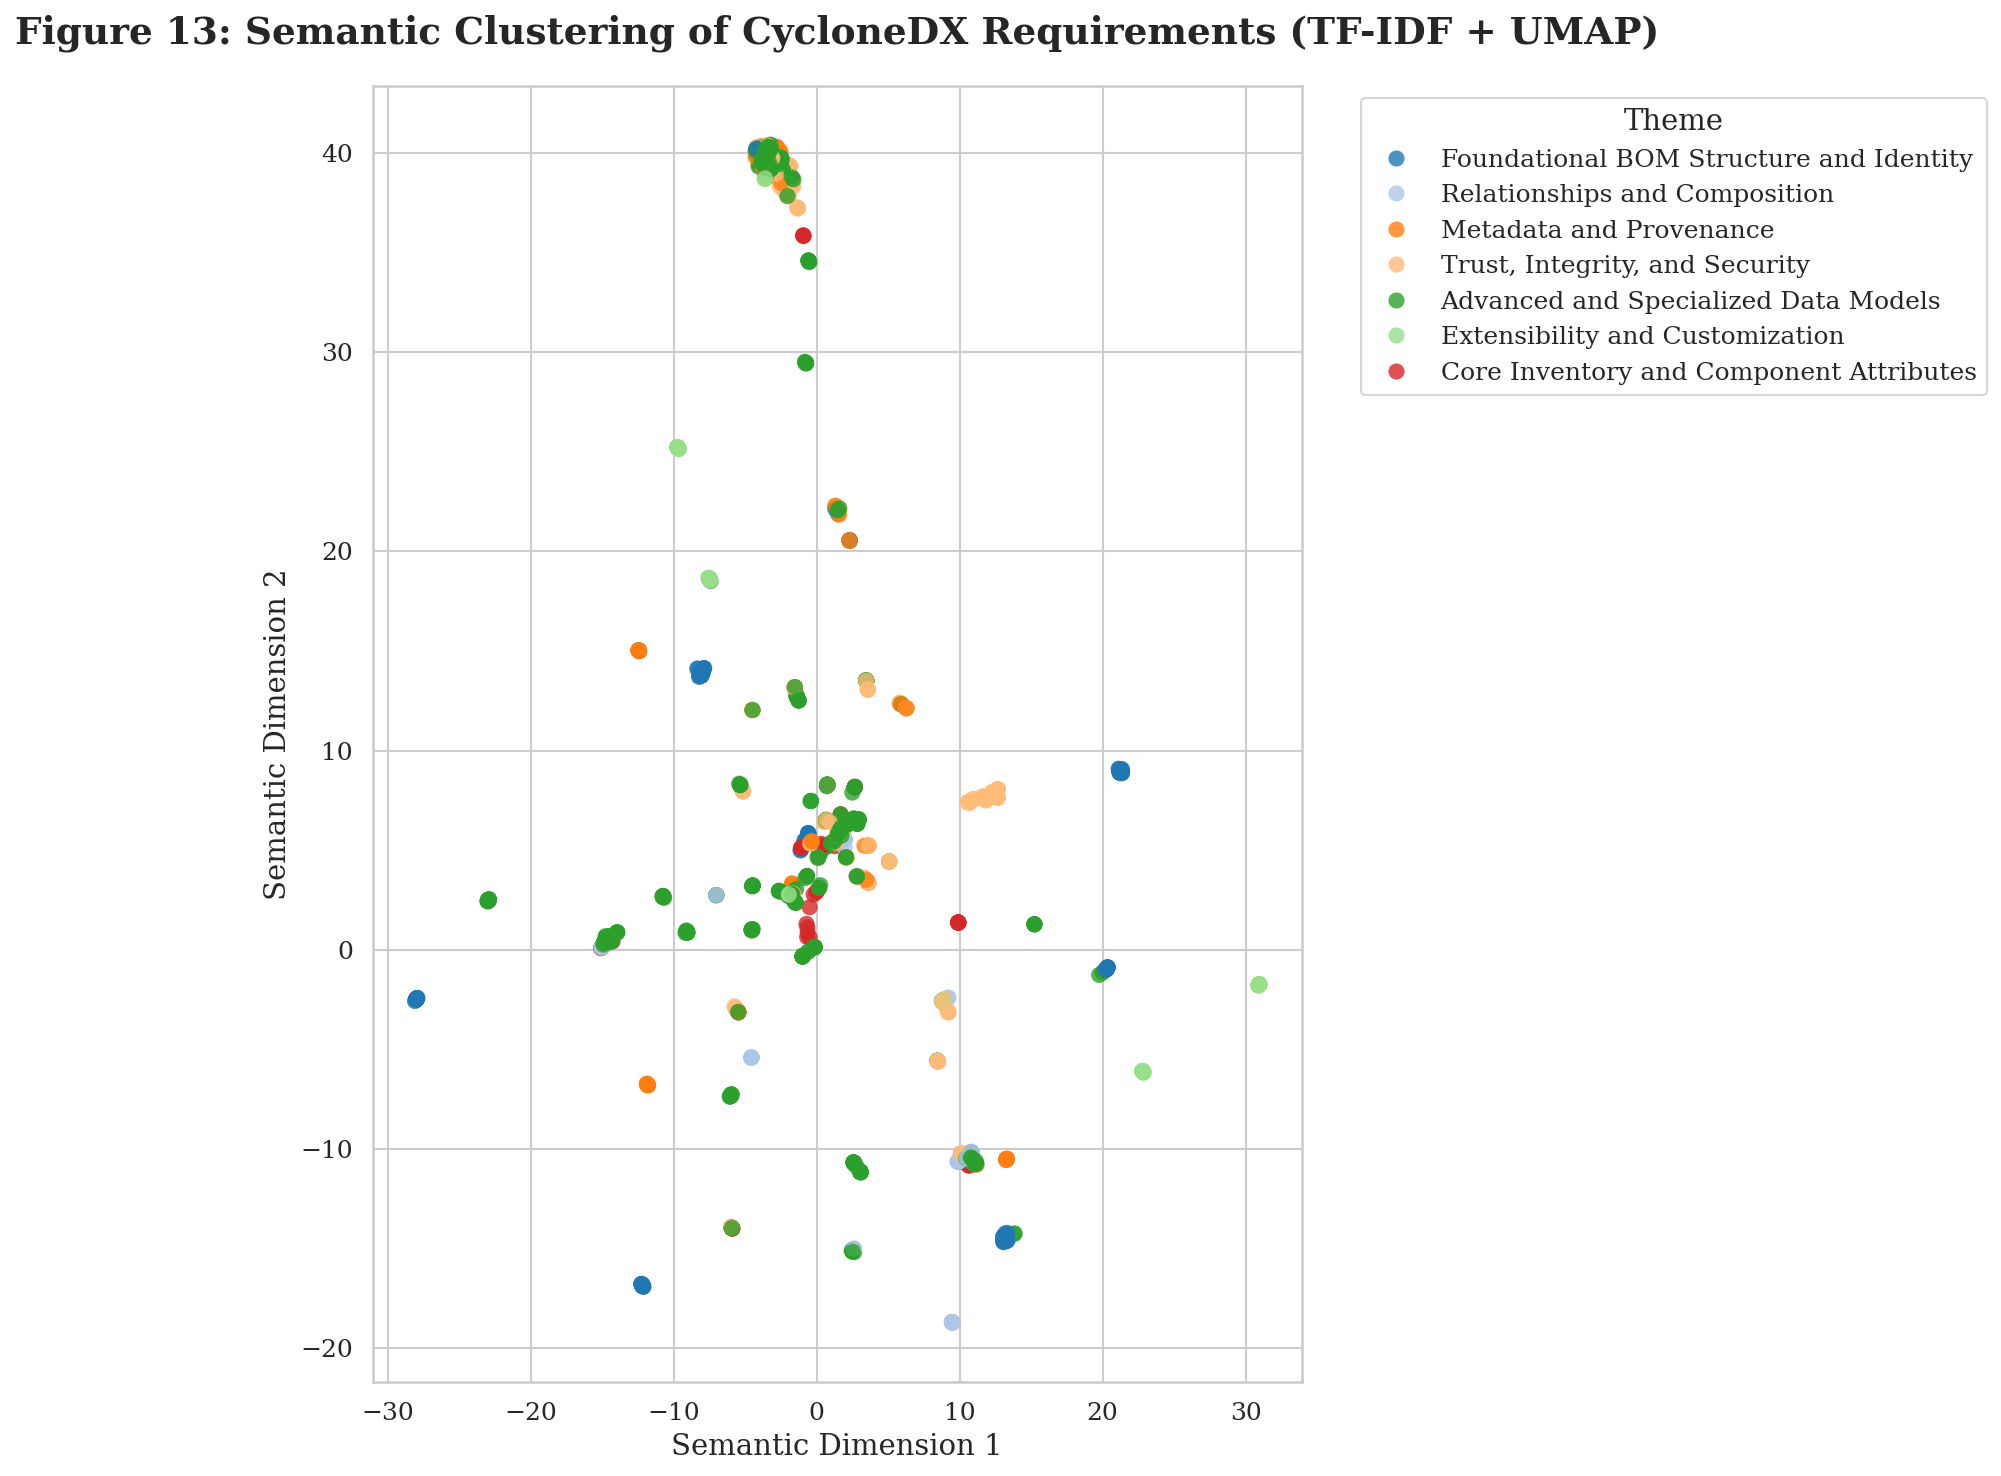

,Avg_IntraTheme_Distance
Relationships and Composition,13.961947
"Trust, Integrity, and Security",21.032495
Core Inventory and Component Attributes,22.668140
Advanced and Specialized Data Models,23.647041
Metadata and Provenance,24.375233
Extensibility and Customization,25.095680
Foundational BOM Structure and Identity,25.354414


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import umap

if not df.empty:
    # --- TF-IDF vectorization ---
    vectorizer = TfidfVectorizer(max_features=2000, stop_words='english')
    X_tfidf = vectorizer.fit_transform(df['Recommendation / Requirement'].fillna(''))

    # --- Dimensionality reduction with UMAP ---
    reducer = umap.UMAP(random_state=42, n_neighbors=15, min_dist=0.1)
    X_umap = reducer.fit_transform(X_tfidf)

    df_umap = pd.DataFrame(X_umap, columns=['UMAP_1', 'UMAP_2'])
    df_umap['Theme'] = df['Theme'].values

    plt.figure(figsize=(12, 10))
    sns.scatterplot(data=df_umap, x='UMAP_1', y='UMAP_2', hue='Theme', palette='tab20', s=60, alpha=0.8, edgecolor='none')
    plt.title('Figure 13: Semantic Clustering of CycloneDX Requirements (TF-IDF + UMAP)', pad=20, weight='bold')
    plt.xlabel('Semantic Dimension 1')
    plt.ylabel('Semantic Dimension 2')
    plt.legend(title='Theme', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # --- Optional: Compute theme cohesion (cluster compactness) ---
    from sklearn.metrics import pairwise_distances
    cohesion_scores = {}
    for theme in df_umap['Theme'].unique():
        subset = df_umap[df_umap['Theme'] == theme][['UMAP_1', 'UMAP_2']]
        if len(subset) > 2:
            distances = pairwise_distances(subset)
            cohesion_scores[theme] = np.mean(distances)
    cohesion_df = pd.DataFrame.from_dict(cohesion_scores, orient='index', columns=['Avg_IntraTheme_Distance']).sort_values('Avg_IntraTheme_Distance')
    display(cohesion_df.style.background_gradient(cmap='YlGnBu'))


## 9. Conclusion

This notebook has executed a deep and multi-faceted analysis of the CycloneDX 1.6 specification.  
The generated data and visualizations provide a robust, evidence-based foundation for the thematic and normative analysis sections of our SoK paper.  

**Key takeaways:**
- Heavy emphasis on `REQUIRED` statements.
- Dominance of `Cryptographic Asset Management` and `Internal Referencing` subthemes.
- A clear, hierarchical thematic structure.

These findings collectively reveal the prescriptive priorities and conceptual depth of the CycloneDX specification — forming a solid analytical foundation for subsequent research discussions and standard comparisons.


## 13. Summary of Extended Analysis

These new layers add analytical and interpretive depth:
- **NKSI** quantifies *how strict or flexible* each thematic cluster is.  
- **Sankey Diagram** reveals hierarchical propagation of prescriptive strength.  
- **UMAP Semantic Clusters** expose conceptual proximities and redundancies in the specification’s language.

Together, these extend the notebook from descriptive analytics to **structural and semantic insight** — essential for SoK-style meta-analysis or CHI interpretive framing.
